In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy.stats
import torch
from torch import tensor, Tensor

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import block_formats.quantisation as Q
import plot_utils

plot_utils.configure()

LM_UNDERLAY_ARGS = dict(zorder=0, lw=4, ls=(0, (4, 1)), ms=6, alpha=.5, marker="x")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def sample(n: int, dist: str, scale: float = 1.0, *, seed: int, **args: float) -> Tensor:
    cls = getattr(torch.distributions, dist)
    cls_args = dict(loc=tensor(0.0, dtype=torch.float32, device=DEVICE), scale=tensor(scale, dtype=torch.float32, device=DEVICE))
    if dist == "StudentT":
        cls_args["df"] = tensor(args["dof"], dtype=torch.float32, device=DEVICE)
    torch.manual_seed(int(np.random.SeedSequence(seed).generate_state(1)[0]))
    return cls(**cls_args).sample((n,))

def distribution_name(dist: str, **args: float) -> str:
    if dist in ("Normal", "Laplace"):
        return dist
    if dist == "StudentT":
        return f"t[$\\nu={args['dof']:.0f}$]"
    raise ValueError(f"Unexpected distribution {dist}")

Recommend (Ubuntu):
  sudo apt-get install cm-super dvipng fonts-cmu texlive-latex-extra


## Optimal formats

### `normal_crd_example_4bit`

remote: Updating references: 100% (1/1)           


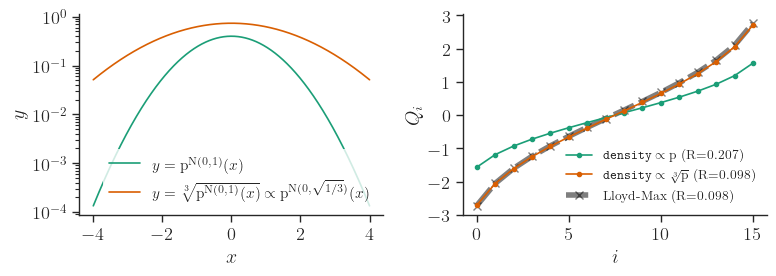

In [25]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 3))

x = torch.linspace(-4, 4, 1001)
ax0.plot(x, scipy.stats.norm.pdf(x), label=r"$y = \mathrm{p}^{\mathrm{N}(0, 1)}(x)$")
ax0.plot(x, scipy.stats.norm.pdf(x)**(1/3), label=r"$y = \sqrt[3]{\mathrm{p}^{\mathrm{N}(0, 1)}(x)} \propto \mathrm{p}^{\mathrm{N}(0, \sqrt{1/3})}(x)$")
ax0.set_yscale("log")
ax0.set_xlabel("$x$")
ax0.set_ylabel(r"$y$")
ax0.legend(loc="lower right")

bits = 4
samples = 2**20

X = sample(samples, "Normal", seed=1)
for fmt in [
        Q.crd_normal(bits, power=1),
        Q.crd_normal(bits),
        Q.lut_lloyd_max(sample(samples, "Normal", seed=2), bits, 1e-4),
    ]:
    name = {
        "CRD-N-RS{1}": r"$\texttt{density} \propto \mathrm{p}$",
        "CRD-N-RS": r"$\texttt{density} \propto \sqrt[3]{\mathrm{p}}$",
        "LM": r"Lloyd-Max",
    }[fmt.name]
    rmse = Q.rmse_norm(X, fmt.quantise(X)).item()
    ax1.plot(fmt.values, label=f"{name} (R={rmse:.3f})",
             **(dict(LM_UNDERLAY_ARGS, c="k") if fmt.name == "LM" else dict(marker="o")))
ax1.set_yticks(list(range(-3, 3+1)))
ax1.set_xlabel("$i$")
ax1.set_ylabel("$Q_i$")
ax1.legend(loc="lower right", fontsize=9.5)

fig.tight_layout()
plot_utils.save("normal_crd_example_4bit")

### `crd_curves_4bit`

remote: Updating references: 100% (1/1)           


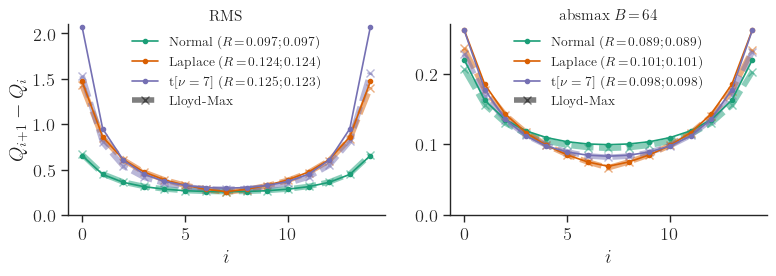

In [11]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 3))

bits = 4
samples = 2**22
lm_iterations = 300
studentt_dof = 7
block_size = 64

dists = [
    dict(dist="Normal", scale=1.0),
    dict(dist="Laplace", scale=2**-0.5),
    dict(dist="StudentT", dof=studentt_dof, scale=((studentt_dof - 2) / studentt_dof) ** .5),
]
for dist, color in zip(dists, plot_utils.PALETTE):
    torch.manual_seed(1)
    X = sample(samples, **dist, seed=1)
    X_LM = sample(samples, **dist, seed=2)
    assert 0.95 <= X.pow(2).mean().sqrt().item() <= 1.05

    lm_fmt = Q.lut_lloyd_max(X_LM, bits, 1e-4)
    block_lm_fmt = Q.lut_lloyd_max(
        X_LM.view(-1, block_size).div(X_LM.view(-1, block_size).abs().amax(-1, keepdim=True)).view(-1),
        bits,
        1e-4,
    )
    if dist["dist"] == "Normal":
        crd_fmt = Q.crd_normal(bits)
        block_crd_fmt = Q.crd_block_normal(bits, block_size)
    if dist["dist"] == "Laplace":
        crd_fmt = Q.crd_laplace(bits)
        block_crd_fmt = Q.crd_block_laplace(bits, block_size)
    if dist["dist"] == "StudentT":
        crd_fmt = Q.crd_t(bits, dist['dof'])
        block_crd_fmt = Q.crd_block_t(bits, block_size, dist['dof'])

    name = distribution_name(**dist)
    rmse = Q.rmse_norm(X, crd_fmt.quantise(X)).item()
    lm_rmse = Q.rmse_norm(X, lm_fmt.quantise(X)).item()
    ax0.plot(tensor(crd_fmt.values[1:]) - tensor(crd_fmt.values[:-1]),
             label=f"{name} ($R\\!=\\!{rmse:.3f} ; {lm_rmse:.3f}$)", c=color, marker="o")
    ax0.plot(tensor(lm_fmt.values[1:]) - tensor(lm_fmt.values[:-1]),
              c=color, **LM_UNDERLAY_ARGS)

    scaling_fmt = Q.LinearScalingFormatV2(block_crd_fmt, Q.BFLOAT16, (block_size,), scaling="absmax")
    block_rmse = Q.rmse_norm(X, scaling_fmt.quantise(X)).item()
    lm_scaling_fmt = Q.LinearScalingFormatV2(block_lm_fmt, Q.BFLOAT16, (block_size,), scaling="absmax")
    lm_block_rmse = Q.rmse_norm(X, lm_scaling_fmt.quantise(X)).item()
    ax1.plot(tensor(block_crd_fmt.values[1:]) - tensor(block_crd_fmt.values[:-1]),
             label=f"{name} ($R\\!=\\!{block_rmse:.3f} ; {lm_block_rmse:.3f}$)", c=color, marker="o")
    ax1.plot(tensor(block_lm_fmt.values[1:]) - tensor(block_lm_fmt.values[:-1]),
             c=color, **LM_UNDERLAY_ARGS)

for ax in [ax0, ax1]:
    ax.set_xlabel("$i$")
    h, _ = ax.get_legend_handles_labels()
    h.append(matplotlib.lines.Line2D([], [], color="k", **LM_UNDERLAY_ARGS, label="Lloyd-Max"))
    ax.legend(handles=h, loc="upper center", fontsize=9.5)

ax0.set_ylim((0, 2.1))
ax1.set_ylim((0, 0.27))

ax0.set_ylabel("$Q_{i+1} - Q_i$")
ax0.set_title("RMS", y=1, va="center")
ax1.set_title(f"absmax $B\\!=\\!{block_size}$", y=1, va="center")

fig.tight_layout()
plot_utils.save("crd_curves_4bit")

### `dist_absmax`

remote: Updating references: 100% (1/1)           


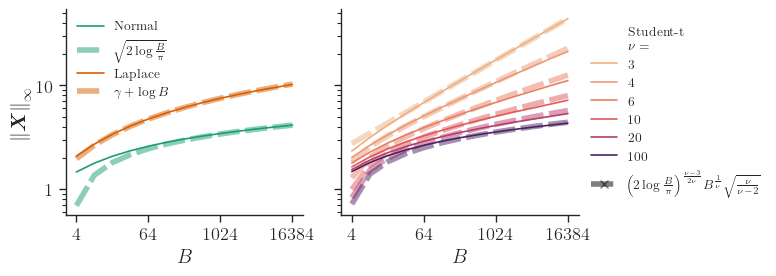

In [17]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 3), sharey=True)

samples = 2**22
B = tensor([2**n for n in range(2, 14+1)])

for color, dist in zip(plot_utils.PALETTE, ["Normal", "Laplace"]):
    X = sample(samples, dist=dist, seed=1)
    ax0.plot(B, [X.view(-1, b).abs().amax(-1).mean().item() for b in B], c=color, label=dist)
    if dist == "Normal":
        model = B.div(torch.pi).log().mul(2).sqrt()
        model_label = r"$\sqrt{2 \log \frac{B}{\pi}}$"
    if dist == "Laplace":
        model = B.log().add(0.57721566)
        model_label = r"$\gamma + \log B$"
    ax0.plot(B, model, **{**LM_UNDERLAY_ARGS, "marker": None}, c=color, label=model_label)
ax0.legend(loc="upper left", fontsize=9.5)

dofs = tensor([3, 4, 6, 10, 20, 100])
for dof, color in zip(dofs, plot_utils.SEQ_PALETTE(matplotlib.colors.LogNorm()(dofs))):
    X = sample(samples, dist="StudentT", dof=dof.item(), seed=1)
    ax1.plot(B, [X.view(-1, b).abs().amax(-1).mean().item() for b in B], c=color, label=f"{dof:.0f}")
    model = B.double().div(torch.pi).log().mul(2).pow((dof-3)/2).mul(B).pow(1/dof).mul((dof/(dof-2)).sqrt())
    ax1.plot(B, model, **{**LM_UNDERLAY_ARGS, "marker": None}, c=color)
model_label = r"$\left(2 \log \frac{B}{\pi}\right)^{\frac{\nu-3}{2 \nu}}\! B^{\frac{1}{\nu}} \sqrt{\frac{\nu}{\nu - 2}}$"
h, _ = ax1.get_legend_handles_labels()
h.insert(0, matplotlib.lines.Line2D([], [], alpha=0, label="Student-t\n$\\nu=$"))
h.append(matplotlib.lines.Line2D([], [], color="k", **LM_UNDERLAY_ARGS, label=model_label))
ax1.legend(handles=h, bbox_to_anchor=(1, 0.5), loc="center left", fontsize=9.5)

for ax in [ax0, ax1]:
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks([4, 64, 1024, 16384])
    ax.xaxis.set_major_formatter("{x:.0f}")
    ax.yaxis.set_major_formatter("{x:.0f}")
    ax.set_xlabel("$B$")
ax0.set_ylabel(r"$\norm{\bm{X}}{\infty}$")

fig.tight_layout()
plot_utils.save("dist_absmax")

## Block vs independent formats on iid data

### `analysis_error_vs_bits`

remote: Updating references: 100% (1/1)           


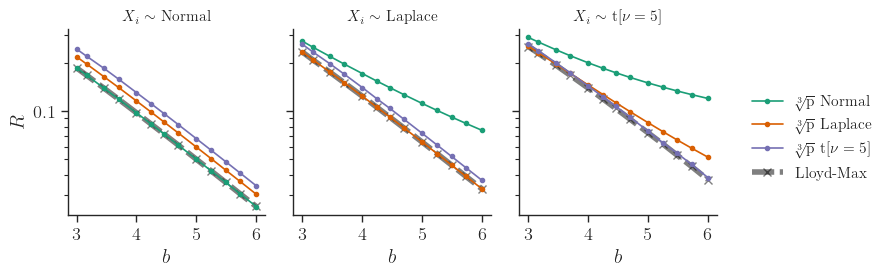

In [ ]:
studentt_dof = 5.0
distributions = [
    dict(dist="Normal"),
    dict(dist="Laplace"),
    dict(dist="StudentT", dof=studentt_dof),
]
methods = [
    (r"$\sqrt[3]{\mathrm{p}}$ Normal", lambda B, _: Q.crd_normal(B)),
    (r"$\sqrt[3]{\mathrm{p}}$ Laplace", lambda B, _: Q.crd_laplace(B)),
    (f"$\\sqrt[3]{{\\mathrm{{p}}}}$ t[$\\nu={studentt_dof:.0f}$]", lambda B, _: Q.crd_t(B, dof=studentt_dof)),
    ("Lloyd-Max", lambda B, X: Q.lut_lloyd_max(X, B, threshold=1e-4, init=("uniform", 3))),
]

fig, axs = plt.subplots(ncols=len(distributions), figsize=(2.5*len(distributions), 3), sharey=True)
for dist, ax in zip(distributions, axs):
    X = sample(2**22, **dist, seed=100)
    X /= X.pow(2).mean().sqrt()

    for name, method in methods:
        fmts = [method(B, X) for B in torch.linspace(3, 6, 13)]
        ax.plot([fmt.count_bits(X.shape) / X.nelement() for fmt in fmts],
                [Q.rmse_norm(X, fmt.quantise(X)).item() for fmt in fmts],
                label=name, **(dict(**LM_UNDERLAY_ARGS, color="k") if name == "Lloyd-Max" else dict(marker="o")))

    ax.set_title(f"$X_i \\sim$ {distribution_name(**dist)}")
    ax.set_yscale("log")
    ax.set_xlabel("$b$")
    ax.yaxis.set_major_formatter("{x:.1f}")
    ax.set_xticks(list(range(3, 6+1)))
axs[0].set_ylabel("$R$")
fig.legend(*axs[0].get_legend_handles_labels(), loc="center left", bbox_to_anchor=(1, 0.5))

fig.tight_layout()
plot_utils.save("analysis_error_vs_bits")